# 🧬 Hi-Cformer Tutorial: Training, Cell Embedding, and Imputation Visualization

This tutorial demonstrates a complete Hi-Cformer workflow using the example dataset shipped with this GitHub repository:

```text
Hi-Cformer/
├── data/
│   └── Ramani2017_dataset/
│       ├── label_info.pickle
│       └── raw/
├── demo/
│   ├── hicformer_params_0.json
│   └── Ramani2017_tutorial.ipynb
└── hicformer/
    ├── train_inference.py
    ├── model.py
    └── utils.py
```

The workflow is:

1. Locate the project root automatically.
2. Load the tutorial dataset from `data/Ramani2017_dataset`.
3. Create a run-specific config based on `demo/hicformer_params_0.json`.
4. Train Hi-Cformer and run inference with the package module:

```bash
python -m hicformer.train_inference --config demo/tutorial_output/hicformer_params_tutorial.json
```

5. Visualize the learned cell embeddings with UMAP.
6. Visualize one imputed contact map from the saved `chr_pred.npy` output.

> The notebook intentionally avoids hard-coded machine-specific paths. It should work when launched from either the repository root or the `demo/` directory.

## 📁 Input files

### 1. Sparse contact matrix folder

Each chromosome is stored as a separate `.npy` file under:

```text
data/Ramani2017_dataset/raw/
├── chr1_sparse_adj.npy
├── chr2_sparse_adj.npy
├── ...
└── chrX_sparse_adj.npy
```

Each file should contain a list or array of sparse matrices, one matrix per cell. The cell order must be consistent across chromosomes.

### 2. Cell metadata file

The metadata file is:

```text
data/Ramani2017_dataset/label_info.pickle
```

It should contain aligned per-cell annotations, for example:

```python
{
    "name": ["cell_1", "cell_2", ...],
    "cell type": ["cell_type_A", "cell_type_B", ...]
}
```

The key used for visualization is controlled by `label_name`.

### 3. Hi-Cformer config file

The tutorial starts from:

```text
demo/hicformer_params_0.json
```

and writes a run-specific config to:

```text
demo/tutorial_output/hicformer_params_tutorial.json
```

The training script saves:

```text
<save_name_prefix><num>cell_embeddings.npy
<save_name_prefix><num>chr_pred.npy
<save_name_prefix>best_main_num<num>_hd<hidden_dim>.pt
```

`cell_embeddings.npy` is used for UMAP visualization.  
`chr_pred.npy` contains the imputed whole-genome upper-triangular vector for each cell.

## 1. Locate the project and set paths

This cell finds the repository root by looking for `setup.py` and the `hicformer/` package folder. It then changes the working directory to the project root so that relative paths inside the config work consistently.

In [1]:
from pathlib import Path
import os
import json
import pickle
import numpy as np


def find_project_root(start=None):
    """Find the Hi-Cformer repository root from the current notebook location."""
    start = Path(start or Path.cwd()).resolve()
    candidates = [start, *start.parents]

    for path in candidates:
        if (path / "setup.py").exists() and (path / "hicformer").is_dir():
            return path

    raise RuntimeError(
        "Could not find the Hi-Cformer project root. "
        "Please launch this notebook from the repository root or from demo/."
    )


PROJECT_DIR = find_project_root()
os.chdir(PROJECT_DIR)

DEMO_DIR = PROJECT_DIR / "demo"
DATASET_DIR = PROJECT_DIR / "data" / "Ramani2017_dataset"
RAW_DIR = DATASET_DIR / "raw"
LABEL_PATH = DATASET_DIR / "label_info.pickle"
BASE_CONFIG_PATH = DEMO_DIR / "config_ramani.json"
OUTPUT_DIR = DEMO_DIR / "tutorial_output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_MODULE = "hicformer.train_inference"


def rel_to_project(path):
    """Return a project-relative path string when possible."""
    path = Path(path)
    try:
        return str(path.resolve().relative_to(PROJECT_DIR))
    except ValueError:
        return str(path)


print("Project directory:", PROJECT_DIR)
print("Dataset directory:", rel_to_project(DATASET_DIR))
print("Raw data folder:", rel_to_project(RAW_DIR))
print("Base config:", rel_to_project(BASE_CONFIG_PATH))
print("Output directory:", rel_to_project(OUTPUT_DIR))

Project directory: /home/wuxiaoqing/Hi-Cformer
Dataset directory: data/Ramani2017_dataset
Raw data folder: data/Ramani2017_dataset/raw
Base config: demo/config_ramani.json
Output directory: demo/tutorial_output


## 2. Load and customize the training configuration

The repository already includes `demo/hicformer_params_0.json`. Here we load it, then update only the paths and output prefix for this tutorial.

All paths written to the config are relative to the project root. Because the notebook changes the working directory to `PROJECT_DIR`, the training module can read them directly.

In [2]:
if not BASE_CONFIG_PATH.exists():
    raise FileNotFoundError(f"Cannot find base config: {BASE_CONFIG_PATH}")

with open(BASE_CONFIG_PATH, "r") as f:
    config = json.load(f)

# Use the dataset distributed with this repository.
label_path = rel_to_project(LABEL_PATH)
raw_path = rel_to_project(RAW_DIR)
save_path = rel_to_project(OUTPUT_DIR)
save_name_prefix = rel_to_project(OUTPUT_DIR / "Ramani2017_hicformer_")

config.update({
    "label_path": label_path,
    "raw_path": raw_path,
    "save_path": save_path,
    "save_name_prefix": save_name_prefix,
})

# Keep the label key from the base config if present; otherwise use the common default.
label_name = config.get("label_name", "cell type")
config["label_name"] = label_name

# Keep the chromosome order from the base config.
# This order must match the order used by train_inference.py when concatenating chr_pred.
chr_list = config["chr_list"]
num = config.get("num", 0)

config_path = OUTPUT_DIR / "hicformer_params_tutorial.json"
with open(config_path, "w") as f:
    json.dump(config, f, indent=2)

print("Tutorial config saved to:", rel_to_project(config_path))
print("label_path:", config["label_path"])
print("raw_path:", config["raw_path"])
print("save_name_prefix:", config["save_name_prefix"])
print("label_name:", label_name)
print("num:", num)
print("chr_list:", chr_list)

Tutorial config saved to: demo/tutorial_output/hicformer_params_tutorial.json
label_path: data/Ramani2017_dataset/label_info.pickle
raw_path: data/Ramani2017_dataset/raw
save_name_prefix: demo/tutorial_output/Ramani2017_hicformer_
label_name: cell type
num: 14
chr_list: ['chr1', 'chr2', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chr20', 'chr21', 'chr22', 'chrX']


## 3. Inspect labels and input matrices

Before training, it is useful to confirm that:

- the metadata file can be loaded;
- the selected `label_name` exists;
- each chromosome file exists;
- the number of cells is consistent across chromosomes.

This cell does **not** train the model. It only validates the tutorial inputs.

In [3]:
# Load labels
with open(PROJECT_DIR / config["label_path"], "rb") as f:
    label_info = pickle.load(f)

if label_name not in label_info:
    raise KeyError(
        f"label_name={label_name!r} is not in label_info. "
        f"Available keys: {list(label_info.keys())}"
    )

labels = list(label_info[label_name])
cell_num = len(labels)

print(f"Loaded {cell_num} cells.")
print(f"Label key: {label_name}")
print("First 5 labels:", labels[:5])

# Inspect chromosome matrix shapes
chr_shapes = {}
for chr_name in chr_list:
    chr_file = PROJECT_DIR / config["raw_path"] / f"{chr_name}_sparse_adj.npy"
    if not chr_file.exists():
        raise FileNotFoundError(f"Missing chromosome file: {rel_to_project(chr_file)}")

    data = np.load(chr_file, allow_pickle=True)
    if len(data) != cell_num:
        raise ValueError(
            f"{chr_name}: expected {cell_num} cells from label file, "
            f"but found {len(data)} matrices."
        )

    first_mat = data[0].toarray()
    chr_shapes[chr_name] = first_mat.shape
    print(f"{chr_name}: {len(data)} cells, matrix shape = {first_mat.shape}")

Loaded 620 cells.
Label key: cell type
First 5 labels: ['HeLa', 'HAP1', 'HeLa', 'HeLa', 'HeLa']
chr1: 620 cells, matrix shape = (250, 250)
chr2: 620 cells, matrix shape = (244, 244)
chr3: 620 cells, matrix shape = (199, 199)
chr4: 620 cells, matrix shape = (192, 192)
chr5: 620 cells, matrix shape = (181, 181)
chr6: 620 cells, matrix shape = (172, 172)
chr7: 620 cells, matrix shape = (160, 160)
chr8: 620 cells, matrix shape = (147, 147)
chr9: 620 cells, matrix shape = (142, 142)
chr10: 620 cells, matrix shape = (136, 136)
chr11: 620 cells, matrix shape = (136, 136)
chr12: 620 cells, matrix shape = (134, 134)
chr13: 620 cells, matrix shape = (116, 116)
chr14: 620 cells, matrix shape = (108, 108)
chr15: 620 cells, matrix shape = (103, 103)
chr16: 620 cells, matrix shape = (91, 91)
chr17: 620 cells, matrix shape = (82, 82)
chr18: 620 cells, matrix shape = (79, 79)
chr19: 620 cells, matrix shape = (60, 60)
chr20: 620 cells, matrix shape = (64, 64)
chr21: 620 cells, matrix shape = (49, 49)
c

## 4. Train Hi-Cformer and run inference

The training and inference are handled by the package module:

```bash
python -m hicformer.train_inference --config demo/tutorial_output/hicformer_params_tutorial.json
```

Using `python -m hicformer.train_inference` is preferred for a packaged GitHub project because `train_inference.py` uses relative imports inside the `hicformer` package.

The script performs:

1. data loading and PCA/TruncatedSVD initialization of chromosome-level features;
2. optional pretraining;
3. main training with validation-loss early stopping;
4. inference over all cells;
5. saving learned embeddings and imputation vectors.

In [4]:
# Run training + inference.
# In a paper/tutorial setting, keeping this as a single command makes the workflow reproducible.

config_path_rel = rel_to_project(config_path)
cmd = f"python -m {TRAIN_MODULE} --config {config_path_rel}"
print(cmd)

# Uncomment to run inside the notebook:
!{cmd}

python -m hicformer.train_inference --config demo/tutorial_output/hicformer_params_tutorial.json
/home/wuxiaoqing/anaconda3/envs/vit/lib/python3.9/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
chr1
chr2
chr3
chr4
chr5
chr6
chr7
chr8
chr9
chr10
chr11
chr12
chr13
chr14
chr15
chr16
chr17
chr18
chr19
chr20
chr21
chr22
chrX
[Epoch 1/180] train_loss=1.532343 val_loss=1.075849
[Epoch 2/180] train_loss=0.873182 val_loss=0.845499
[Epoch 3/180] train_loss=0.692542 val_loss=0.772439
[Epoch 4/180] train_loss=0.620312 val_loss=0.753960
[Epoch 5/180] train_loss=0.584389 val_loss=0.751107
[Epoch 6/180] train_loss=0.591293 val_loss=0.737885
[Epoch 7/180] train_loss=0.604009 val_loss=0.745128
[Epoch 8/180] 

## 5. Locate output files

After the training script finishes, the following files should be available:

- `cell_embeddings.npy`: learned cell embeddings;
- `chr_pred.npy`: imputed whole-genome upper-triangular vectors;
- `best_main_num<num>_hd<hidden_dim>.pt`: best checkpoint selected by validation loss.

In [5]:
def project_path(path_like):
    """Resolve a path that may be relative to the project root."""
    path = Path(path_like)
    if path.is_absolute():
        return path
    return PROJECT_DIR / path

embedding_path = project_path(config["save_name_prefix"] + str(num) + "cell_embeddings.npy")
chr_pred_path = project_path(config["save_name_prefix"] + str(num) + "chr_pred.npy")
checkpoint_path = project_path(
    config["save_name_prefix"] + f"best_main_num{num}_hd{config['hidden_dim']}.pt"
)

print("Embedding file:", rel_to_project(embedding_path))
print("Imputation file:", rel_to_project(chr_pred_path))
print("Checkpoint file:", rel_to_project(checkpoint_path))

if not embedding_path.exists():
    print("WARNING: embedding file not found. Run the training cell first.")
if not chr_pred_path.exists():
    print("WARNING: chr_pred file not found. Make sure train_inference.py saves chr_pred during inference.")

Embedding file: demo/tutorial_output/Ramani2017_hicformer_14cell_embeddings.npy
Imputation file: demo/tutorial_output/Ramani2017_hicformer_14chr_pred.npy
Checkpoint file: demo/tutorial_output/Ramani2017_hicformer_best_main_num14_hd64.pt


## 6. Visualize cell embeddings with UMAP

This section keeps the original tutorial's embedding visualization workflow:

1. load the learned cell embeddings;
2. standardize features;
3. run UMAP;
4. color cells by the selected metadata label.

Embedding matrix shape: (620, 64)


/home/wuxiaoqing/anaconda3/envs/vit/lib/python3.9/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


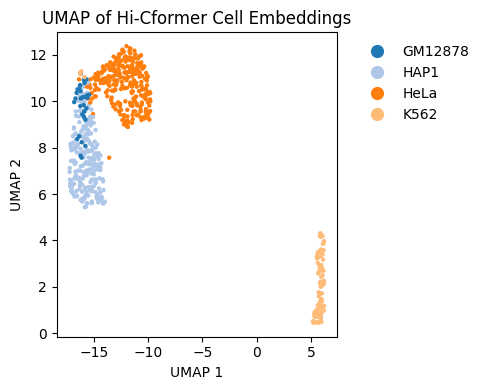

In [6]:
from sklearn.preprocessing import StandardScaler
from umap import UMAP
import matplotlib.pyplot as plt
import seaborn as sns

cell_embed_matrix = np.load(embedding_path)
print("Embedding matrix shape:", cell_embed_matrix.shape)

# Standardize embeddings before UMAP
latent_std = StandardScaler().fit_transform(cell_embed_matrix)

umap_result = UMAP(
    n_components=2,
    random_state=42,
    n_neighbors=15,
    min_dist=0.3
).fit_transform(latent_std)

# Plot
plt.figure(figsize=(5, 4))
sorted_categories = sorted(set(labels))
palette = sns.color_palette("tab20", n_colors=len(sorted_categories))

sns.scatterplot(
    x=umap_result[:, 0],
    y=umap_result[:, 1],
    hue=labels,
    hue_order=sorted_categories,
    palette=palette,
    s=10,
    linewidth=0
)

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", markerscale=3, frameon=False)
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("UMAP of Hi-Cformer Cell Embeddings")
plt.tight_layout()
plt.show()

## 7. Reconstruct one chromosome from `chr_pred`

`chr_pred.npy` stores one vector per cell. For each cell, the vector is the concatenation of upper-triangular contact vectors from all chromosomes in `chr_list`.

For a chromosome with matrix size `H × H`, the upper-triangular vector length is:

```python
H * (H + 1) // 2
```

Therefore, to visualize a single chromosome:

1. calculate the upper-triangular length of each chromosome;
2. find the slice corresponding to the selected chromosome;
3. put that slice back into the upper triangle of an `H × H` matrix;
4. mirror the upper triangle to the lower triangle to obtain a symmetric contact map.

This reconstruction mirrors the model's `expand_tensor` behavior, which keeps the upper triangle including the diagonal.

In [7]:
def upper_tri_to_symmetric(vec, matrix_size, include_diagonal=True):
    """
    Convert an upper-triangular vector back to a symmetric square matrix.

    Parameters
    ----------
    vec : array-like
        Flattened upper-triangular values.
    matrix_size : int
        Height/width of the square matrix.
    include_diagonal : bool
        Whether the vector includes diagonal entries. Hi-Cformer's expand_tensor uses triu(),
        so the diagonal is included.

    Returns
    -------
    mat : np.ndarray
        Symmetric reconstructed matrix.
    """
    vec = np.asarray(vec)
    k = 0 if include_diagonal else 1
    tri_idx = np.triu_indices(matrix_size, k=k)

    expected_len = len(tri_idx[0])
    if vec.shape[0] != expected_len:
        raise ValueError(
            f"Vector length mismatch: got {vec.shape[0]}, expected {expected_len} "
            f"for matrix_size={matrix_size}."
        )

    mat = np.zeros((matrix_size, matrix_size), dtype=vec.dtype)
    mat[tri_idx] = vec

    # Mirror upper triangle to lower triangle.
    if include_diagonal:
        mat = mat + mat.T - np.diag(np.diag(mat))
    else:
        mat = mat + mat.T

    return mat


def get_chr_slices(raw_path, chr_list):
    """
    Compute vector slice positions for each chromosome in the concatenated chr_pred vector.

    The order must be exactly the same as the chr_list used by train_inference.py.
    """
    raw_path = project_path(raw_path)
    chr_slices = {}
    start = 0

    for chr_name in chr_list:
        chr_file = raw_path / f"{chr_name}_sparse_adj.npy"
        data = np.load(chr_file, allow_pickle=True)
        mat0 = data[0].toarray()
        H = mat0.shape[0]
        L = H * (H + 1) // 2

        chr_slices[chr_name] = {
            "start": start,
            "end": start + L,
            "matrix_size": H,
            "vector_length": L,
        }
        start += L

    return chr_slices


chr_slices = get_chr_slices(config["raw_path"], chr_list)

for chr_name in chr_list[:5]:
    info = chr_slices[chr_name]
    print(
        f"{chr_name}: slice [{info['start']}, {info['end']}), "
        f"matrix_size={info['matrix_size']}, vector_length={info['vector_length']}"
    )

print("Total chr_pred length expected:", chr_slices[chr_list[-1]]["end"])

chr1: slice [0, 31375), matrix_size=250, vector_length=31375
chr2: slice [31375, 61265), matrix_size=244, vector_length=29890
chr3: slice [61265, 81165), matrix_size=199, vector_length=19900
chr4: slice [81165, 99693), matrix_size=192, vector_length=18528
chr5: slice [99693, 116164), matrix_size=181, vector_length=16471
Total chr_pred length expected: 240166


## 8. Visualize one imputed contact map

Here we select one cell and one chromosome, then compare:

- the raw sparse input contact map;
- the Hi-Cformer imputed contact map;
- the difference between imputed and raw maps.

For visualization only, we apply `log1p` to make sparse Hi-C contact maps easier to inspect.

In [8]:
# --------------------------
# Choose one cell and chromosome
# --------------------------
cell_idx = 0
chr_name = chr_list[0]

# You can also choose randomly:
# rng = np.random.default_rng(1)
# cell_idx = int(rng.integers(0, cell_num))
# chr_name = str(rng.choice(chr_list))

print(f"Selected cell index: {cell_idx}")
print(f"Selected chromosome: {chr_name}")
print(f"Cell label: {labels[cell_idx]}")

# --------------------------
# Load raw input matrix
# --------------------------
chr_file = project_path(config["raw_path"]) / f"{chr_name}_sparse_adj.npy"
raw_chr_data = np.load(chr_file, allow_pickle=True)
raw_mat = raw_chr_data[cell_idx].toarray().astype(float)

# --------------------------
# Load imputation vector and reconstruct selected chromosome
# --------------------------
chr_pred = np.load(chr_pred_path)
print("chr_pred matrix shape:", chr_pred.shape)

info = chr_slices[chr_name]
pred_vec = chr_pred[cell_idx, info["start"]:info["end"]]
imputed_mat = upper_tri_to_symmetric(pred_vec, matrix_size=info["matrix_size"])

print("Raw matrix shape:", raw_mat.shape)
print("Imputed matrix shape:", imputed_mat.shape)

Selected cell index: 0
Selected chromosome: chr1
Cell label: HeLa
chr_pred matrix shape: (620, 240166)
Raw matrix shape: (250, 250)
Imputed matrix shape: (250, 250)


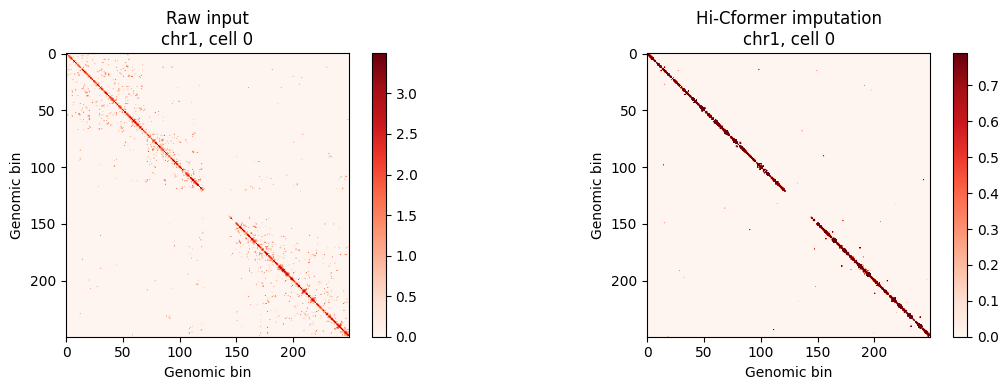

In [21]:
# --------------------------
# Plot raw and imputed contact maps
# --------------------------
raw_show = np.log1p(raw_mat)
imputed_show = np.log1p(imputed_mat)


vmax = np.percentile(np.concatenate([raw_show.ravel(), imputed_show.ravel()]), 99.5)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

im0 = axes[0].imshow(raw_show, cmap="Reds", vmax = np.percentile(raw_show.ravel(), 99.9))
axes[0].set_title(f"Raw input\n{chr_name}, cell {cell_idx}")
axes[0].set_xlabel("Genomic bin")
axes[0].set_ylabel("Genomic bin")

im1 = axes[1].imshow(imputed_show, cmap="Reds", vmax = np.percentile(imputed_show.ravel(), 99))
axes[1].set_title(f"Hi-Cformer imputation\n{chr_name}, cell {cell_idx}")
axes[1].set_xlabel("Genomic bin")
axes[1].set_ylabel("Genomic bin")


plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)


plt.tight_layout()
plt.show()

## Notes

- The tutorial is written for the repository layout shown at the top of this notebook.
- The notebook uses project-relative paths in the JSON config, not machine-specific absolute paths.
- The training command uses `python -m hicformer.train_inference` so that package-relative imports work correctly.
- The `chr_pred` vector follows the same chromosome order as `chr_list`.
- For each chromosome, Hi-Cformer stores only the upper triangle, including the diagonal.
- The reconstruction function above mirrors the upper triangle to obtain a symmetric contact map.
- If your local `train_inference.py` does not yet save `chr_pred.npy`, add `chr_preds.append(chr_pred.cpu())` in the inference loop before running this tutorial.